# 🏀 NBA Betting Model

---

## How to use this every day

### Step 1 — Open Jupyter and run every cell from top to bottom
Just click on Cell 1 and keep hitting **Shift + Enter** going down.
This takes about 2 minutes and does everything automatically:
- Pulls today's NBA games
- Grabs the live betting lines from DraftKings/FanDuel
- Runs the model and shows you the picks
- Checks last night's scores and settles your bets
- Updates your profit/loss chart

### Step 2 — Look at the picks in Cell 8
This tells you what the model likes for tonight.
Green = bet this · Red = avoid · Confidence % tells you how strong the pick is.

### Step 3 — After the games finish (around 11:30pm ET)
Just run Cell 11 again.
It will automatically check ESPN for the final scores,
mark your bets as wins or losses, and update your chart.

---

## One rule
**Always start from Cell 1 and run down in order.**
Never skip cells — they depend on each other.

---

## What each cell does in plain English

| Cell | What it does |
|------|-------------|
| 1 | Loads the tools needed to run everything |
| 2 | Sets up your API key and team names |
| 3 | Grabs real team stats from NBA.com |
| 4 | Finds out what games are on today |
| 5 | Gets the live betting lines from DraftKings and FanDuel |
| 6 | Pulls final scores from ESPN |
| 7 | The brain of the model — all the math |
| 8 | Shows you today's picks with charts |
| 9 | Sets up the bet tracker |
| 10 | Figures out if your bets won or lost |
| 11 | Updates your chart with wins and losses |
| 12 | Shows you your full bet history |
| 13 | Runs everything at once — use this once you're comfortable |

---

> ⚠️ For entertainment only. Please gamble responsibly. 1-800-GAMBLER

In [1]:
import requests
import time
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.live.nba.endpoints import scoreboard
from nba_api.stats.endpoints import teamestimatedmetrics
from datetime import datetime, date

print("✅ Imports done")

✅ Imports done


In [2]:
# ── SETTINGS ────────────────────────────────────────────────────
ODDS_API_KEY   = "6650ff3bddae2d463d065a7302974d6c"
TRACKER_FILE   = "bet_log.json"
HOME_COURT_ADV = 3.0
NET_RTG_WEIGHT = 0.85

# ── TEAM NAME → TRICODE MAP ──────────────────────────────────────
NAME_TO_CODE = {
    "Atlanta Hawks": "ATL",
    "Boston Celtics": "BOS",
    "Brooklyn Nets": "BKN",
    "Charlotte Hornets": "CHA",
    "Chicago Bulls": "CHI",
    "Cleveland Cavaliers": "CLE",
    "Dallas Mavericks": "DAL",
    "Denver Nuggets": "DEN",
    "Detroit Pistons": "DET",
    "Golden State Warriors": "GSW",
    "Houston Rockets": "HOU",
    "Indiana Pacers": "IND",
    "Los Angeles Clippers": "LAC",
    "Los Angeles Lakers": "LAL",
    "Memphis Grizzlies": "MEM",
    "Miami Heat": "MIA",
    "Milwaukee Bucks": "MIL",
    "Minnesota Timberwolves": "MIN",
    "New Orleans Pelicans": "NOP",
    "New York Knicks": "NYK",
    "Oklahoma City Thunder": "OKC",
    "Orlando Magic": "ORL",
    "Philadelphia 76ers": "PHI",
    "Phoenix Suns": "PHX",
    "Portland Trail Blazers": "POR",
    "Sacramento Kings": "SAC",
    "San Antonio Spurs": "SAS",
    "Toronto Raptors": "TOR",
    "Utah Jazz": "UTA",
    "Washington Wizards": "WAS",
}

print("✅ Settings loaded")
print(f"   API key ending in: ...{ODDS_API_KEY[-6:]}")
print(f"   {len(NAME_TO_CODE)} teams mapped")

✅ Settings loaded
   API key ending in: ...974d6c
   30 teams mapped


In [3]:
# ── LIVE TEAM RATINGS FROM NBA.COM ──────────────────────────────
def get_live_team_stats():
    time.sleep(1)
    metrics = teamestimatedmetrics.TeamEstimatedMetrics(
        season="2025-26",
        season_type="Playoffs"
    )
    df = metrics.get_data_frames()[0]
    df["team"] = df["TEAM_NAME"].map(NAME_TO_CODE)
    df = df.dropna(subset=["team"]).set_index("team")
    return pd.DataFrame({
        "off_rtg": df["E_OFF_RATING"],
        "def_rtg": df["E_DEF_RATING"],
        "net_rtg": df["E_NET_RATING"],
        "pace":    df["E_PACE"],
        "wins":    df["W"],
        "losses":  df["L"],
        "win_pct": df["W_PCT"],
    })

# RUN IT
df_teams = get_live_team_stats()
print(f"✅ Live ratings pulled from NBA.com")
print(f"   {len(df_teams)} teams loaded\n")
print(df_teams[["off_rtg","def_rtg","net_rtg","wins","losses"]].round(2).to_string())

✅ Live ratings pulled from NBA.com
   16 teams loaded

      off_rtg  def_rtg  net_rtg  wins  losses
team                                         
PHI     106.8    114.2     -7.5     4       5
MIN     106.5    107.6     -1.1     5       3
CLE     110.4    110.1      0.2     4       4
NYK     120.6    101.6     19.0     6       2
DET     106.1    100.6      5.5     5       3
SAS     114.1    100.0     14.0     5       2
TOR     107.6    109.3     -1.7     3       4
ORL      98.8    103.5     -4.8     3       4
BOS     110.6    107.6      3.0     3       4
LAL     104.1    104.6     -0.4     4       3
DEN     105.8    110.2     -4.4     2       4
ATL     101.4    119.1    -17.7     2       4
HOU     101.6    104.2     -2.6     2       4
POR     100.7    113.2    -12.5     1       4
OKC     122.5    104.7     17.8     5       0
PHX     106.6    124.1    -17.4     0       4


In [4]:
# ── TODAY'S GAMES FROM NBA.COM ───────────────────────────────────
def get_todays_games():
    board = scoreboard.ScoreBoard()
    games = board.games.get_dict()
    return [
        {
            "home": g["homeTeam"]["teamTricode"],
            "away": g["awayTeam"]["teamTricode"],
            "time": g["gameStatusText"],
        }
        for g in games
    ]

# RUN IT
games = get_todays_games()
print(f"✅ Today's games from NBA.com")
print(f"   {len(games)} game(s) found\n")
for g in games:
    print(f"   🏀 {g['away']} @ {g['home']}  |  {g['time']}")

✅ Today's games from NBA.com
   2 game(s) found

   🏀 CLE @ DET  |  7:00 pm ET
   🏀 LAL @ OKC  |  9:30 pm ET


In [5]:
# ── LIVE ODDS FROM THE ODDS API ──────────────────────────────────
def get_live_odds():
    url = (
        "https://api.the-odds-api.com/v4/sports/basketball_nba/odds/"
        f"?apiKey={ODDS_API_KEY}"
        "&regions=us&markets=spreads,totals,h2h"
        "&oddsFormat=american&bookmakers=draftkings,fanduel"
    )
    r = requests.get(url, timeout=10)
    print(f"   API requests remaining: "
          f"{r.headers.get('x-requests-remaining', 'unknown')}")

    odds_dict = {}
    for g in r.json():
        home_name = g.get("home_team", "")
        away_name = g.get("away_team", "")
        home_code = NAME_TO_CODE.get(home_name)
        away_code = NAME_TO_CODE.get(away_name)
        if not home_code or not away_code:
            continue
        entry = {
            "spread":  None,
            "total":   None,
            "home_ml": None,
            "away_ml": None,
        }
        for book in g.get("bookmakers", []):
            for mkt in book.get("markets", []):
                if mkt["key"] == "spreads":
                    for o in mkt["outcomes"]:
                        if o["name"] == home_name:
                            entry["spread"] = o.get("point")
                elif mkt["key"] == "totals":
                    for o in mkt["outcomes"]:
                        if o["name"] == "Over":
                            entry["total"] = o.get("point")
                elif mkt["key"] == "h2h":
                    for o in mkt["outcomes"]:
                        if o["name"] == home_name:
                            entry["home_ml"] = o.get("price")
                        elif o["name"] == away_name:
                            entry["away_ml"] = o.get("price")
            break  # use first book only
        odds_dict[(away_code, home_code)] = entry
    return odds_dict

# RUN IT
odds = get_live_odds()
print(f"✅ Live odds pulled from The Odds API")
print(f"   {len(odds)} game(s) found\n")
for (away, home), line in odds.items():
    print(f"   {away} @ {home}")
    print(f"      Spread: {line['spread']}  |  "
          f"Total: {line['total']}  |  "
          f"ML: {line['home_ml']} / {line['away_ml']}")

   API requests remaining: 470
✅ Live odds pulled from The Odds API
   4 game(s) found

   CLE @ DET
      Spread: -3.5  |  Total: 215.5  |  ML: -162 / 136
   LAL @ OKC
      Spread: -15.5  |  Total: 210.5  |  ML: -950 / 625
   NYK @ PHI
      Spread: -1.5  |  Total: 213.5  |  ML: -120 / 102
   SAS @ MIN
      Spread: 4.5  |  Total: 216.5  |  ML: 164 / -196


In [6]:
# ── REAL FINAL SCORES FROM ESPN ──────────────────────────────────
def get_espn_scores(days_back=3):
    finals = {}
    today  = pd.Timestamp.now()
    for i in range(days_back):
        day      = today - pd.Timedelta(days=i)
        date_str = day.strftime("%Y%m%d")
        url = (
            f"https://site.api.espn.com/apis/site/v2/sports/"
            f"basketball/nba/scoreboard?dates={date_str}"
        )
        try:
            r      = requests.get(url, timeout=10)
            events = r.json().get("events", [])
            for e in events:
                status = e["status"]["type"]["description"]
                comps  = e["competitions"][0]
                teams  = comps["competitors"]
                home   = next(t for t in teams if t["homeAway"] == "home")
                away   = next(t for t in teams if t["homeAway"] == "away")
                h_code = NAME_TO_CODE.get(
                    home["team"]["displayName"],
                    home["team"]["abbreviation"]
                )
                a_code = NAME_TO_CODE.get(
                    away["team"]["displayName"],
                    away["team"]["abbreviation"]
                )
                h_score = int(home["score"]) if home["score"] else 0
                a_score = int(away["score"]) if away["score"] else 0
                finals[(a_code, h_code)] = {
                    "home":       h_code,
                    "away":       a_code,
                    "home_score": h_score,
                    "away_score": a_score,
                    "status":     status,
                    "date":       date_str,
                }
            time.sleep(0.3)
        except Exception as e:
            print(f"   ⚠️ ESPN error {date_str}: {e}")
    return finals

# RUN IT
finals = get_espn_scores(days_back=3)
print(f"✅ Real scores from ESPN")
print(f"   {len(finals)} game(s) found\n")
for (away, home), s in finals.items():
    status_icon = "✅ Final" if s["status"] == "Final" else f"🔴 {s['status']}"
    print(f"   {away} {s['away_score']} @ {home} {s['home_score']}"
          f"  |  {status_icon}  |  {s['date']}")

✅ Real scores from ESPN
   4 game(s) found

   CLE 101 @ DET 111  |  ✅ Final  |  20260505
   LAL 90 @ OKC 108  |  ✅ Final  |  20260505
   PHI 102 @ NYK 108  |  ✅ Final  |  20260506
   MIN 95 @ SAS 133  |  ✅ Final  |  20260506


In [7]:
# ── MODEL FUNCTIONS ──────────────────────────────────────────────
def prob_to_american(prob):
    prob = max(0.01, min(0.99, prob))
    if prob >= 0.5:
        return int(-(prob / (1 - prob)) * 100)
    return int(((1 - prob) / prob) * 100)

def american_to_prob(odds):
    if odds < 0:
        return (-odds) / (-odds + 100)
    return 100 / (odds + 100)

def calc_spread(home, away, neutral=False):
    h    = df_teams.loc[home]
    a    = df_teams.loc[away]
    diff = h["net_rtg"] - a["net_rtg"]
    hca  = 0 if neutral else HOME_COURT_ADV
    return round(-(diff * NET_RTG_WEIGHT + hca), 1)

def calc_total(home, away):
    h        = df_teams.loc[home]
    a        = df_teams.loc[away]
    avg_pace = (h["pace"] + a["pace"]) / 2
    return round(
        ((h["off_rtg"] + a["off_rtg"]) / 2) * (avg_pace / 100) * 2 * 0.97,
        1
    )

def calc_winprob(home, away):
    h   = df_teams.loc[home]
    a   = df_teams.loc[away]
    raw = (h["win_pct"] * 0.55
           + (1 - a["win_pct"]) * 0.35
           + HOME_COURT_ADV / 100)
    return round(min(0.90, max(0.10, raw)), 3)

def sharp_signal(bets_pct, money_pct):
    delta = money_pct - bets_pct
    if   delta >=  15: return "STRONG SHARP ✅", delta, -0.50,  0.05
    elif delta >=   8: return "Moderate sharp",  delta, -0.25,  0.02
    elif delta <= -15: return "SHARP FADE ⚠️",   delta,  0.50, -0.04
    elif delta <=  -8: return "Moderate fade",   delta,  0.25, -0.02
    return "Neutral", delta, 0, 0

def predict_game(home, away,
                 market_spread, market_total,
                 mkt_home_ml, mkt_away_ml,
                 bets_pct=50, money_pct=50,
                 injury_adj=0, is_playoff=True):

    # Check both teams exist in live data
    missing = [t for t in [home, away] if t not in df_teams.index]
    if missing:
        print(f"  ⚠️ Missing live data for: {missing}")
        return None

    model_spread = calc_spread(home, away) + injury_adj
    model_total  = calc_total(home, away)
    home_prob    = calc_winprob(home, away)
    away_prob    = round(1 - home_prob, 3)

    sig, delta, nudge, conf_boost = sharp_signal(bets_pct, money_pct)
    adj_spread  = model_spread + nudge
    spread_edge = market_spread - adj_spread
    total_edge  = market_total  - model_total

    confidence  = min(0.88,
                      0.50
                      + abs(spread_edge) * 0.035
                      + abs(total_edge)  * 0.008
                      + conf_boost
                      + (0.06 if is_playoff else 0))

    spread_pick = (f"LAY {home}"    if spread_edge >  0.5 else
                   f"TAKE {away} +" if spread_edge < -0.5 else
                   "PASS")
    total_pick  = (f"UNDER {market_total} 🎯" if total_edge >  1.5 else
                   f"OVER {market_total} 🎯"  if total_edge < -1.5 else
                   "PASS")
    tier        = ("⭐ A — Strong" if confidence >= 0.68 else
                   "B — Moderate"  if confidence >= 0.58 else
                   "C — Low")

    return {
        "matchup":        f"{away} @ {home}",
        "home":           home,
        "away":           away,
        "model_spread":   adj_spread,
        "market_spread":  market_spread,
        "spread_edge":    round(spread_edge, 1),
        "spread_pick":    spread_pick,
        "model_total":    model_total,
        "market_total":   market_total,
        "total_edge":     round(total_edge, 1),
        "total_pick":     total_pick,
        "home_win_prob":  home_prob,
        "away_win_prob":  away_prob,
        "model_home_ml":  prob_to_american(home_prob),
        "model_away_ml":  prob_to_american(away_prob),
        "mkt_home_ml":    mkt_home_ml,
        "mkt_away_ml":    mkt_away_ml,
        "sharp_signal":   sig,
        "sharp_delta":    delta,
        "confidence":     round(confidence, 2),
        "tier":           tier,
    }

print("✅ Model functions ready")

✅ Model functions ready


📊 Running model on today's games...



C:\Users\Mak\AppData\Local\Temp\ipykernel_11932\2093689673.py:182: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\Mak\AppData\Local\Temp\ipykernel_11932\2093689673.py:183: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig("todays_picks.png", dpi=150,
C:\Users\Mak\AppData\Local\Temp\ipykernel_11932\2093689673.py:183: UserWarning: Glyph 127936 (\N{BASKETBALL AND HOOP}) missing from font(s) DejaVu Sans.
  plt.savefig("todays_picks.png", dpi=150,
C:\Users\Mak\AppData\Local\Temp\ipykernel_11932\2093689673.py:183: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig("todays_picks.png", dpi=150,
C:\Users\Mak\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Mak\AppD

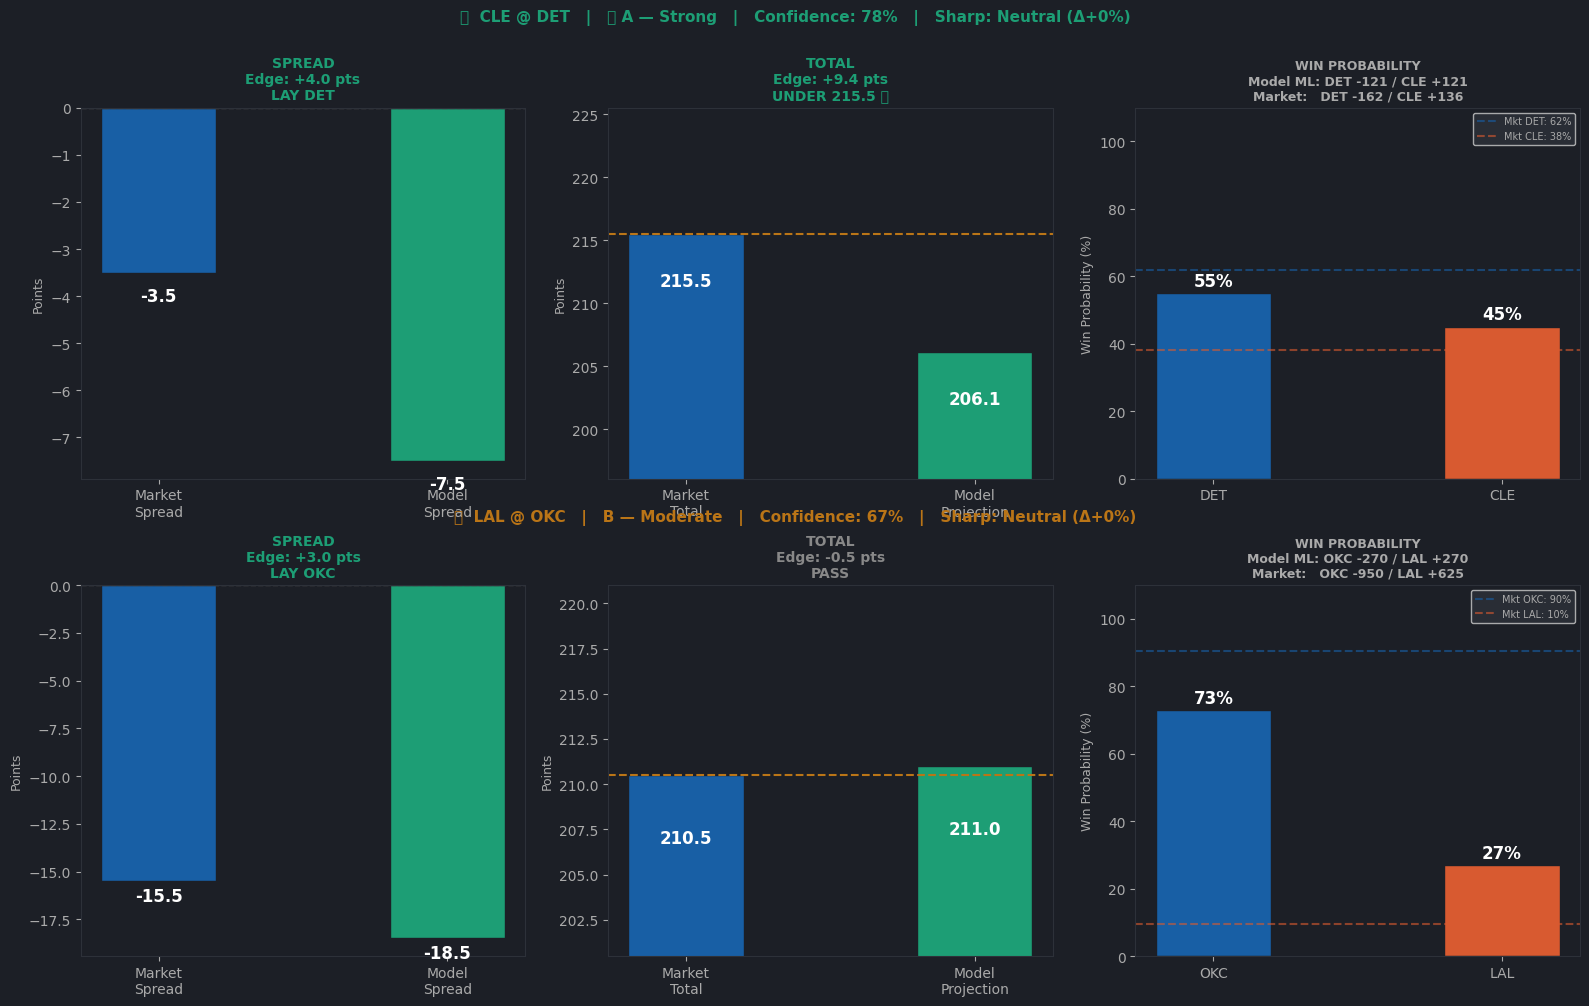

✅ Chart saved as todays_picks.png
   2 game(s) modeled
   ⚠️  For entertainment only. 1-800-GAMBLER


In [8]:
# ── RUN MODEL + VISUAL COMPARISON ───────────────────────────────
print(f"📊 Running model on today's games...\n")

results = []
for g in games:
    home = g["home"]
    away = g["away"]
    line = (odds.get((away, home)) or odds.get((home, away)))
    if not line or line["spread"] is None:
        print(f"  ⚠️ No odds for {away} @ {home} — skipping")
        continue
    pred = predict_game(
        home          = home,
        away          = away,
        market_spread = line["spread"],
        market_total  = line["total"],
        mkt_home_ml   = line["home_ml"],
        mkt_away_ml   = line["away_ml"],
        is_playoff    = True,
    )
    if not pred:
        continue
    results.append(pred)

# ── VISUAL COMPARISON CHART ──────────────────────────────────────
if not results:
    print("  No games to model today.")
else:
    n    = len(results)
    fig, axes = plt.subplots(n, 3, figsize=(16, 5 * n))
    fig.patch.set_facecolor("#1c1f26")

    # Handle single game (axes won't be 2D)
    if n == 1:
        axes = [axes]

    for i, pred in enumerate(results):
        ax_spread = axes[i][0]
        ax_total  = axes[i][1]
        ax_ml     = axes[i][2]

        matchup   = pred["matchup"]
        home      = pred["home"]
        away      = pred["away"]

        tier_color = ("#1D9E75" if "A" in pred["tier"] else
                      "#BA7517" if "B" in pred["tier"] else "#D85A30")

        # Row title
        fig.text(
            0.5,
            1.0 - (i / n) - 0.01,
            f"🏀  {matchup}   |   {pred['tier']}   |   "
            f"Confidence: {pred['confidence']:.0%}   |   "
            f"Sharp: {pred['sharp_signal']} "
            f"(Δ{pred['sharp_delta']:+.0f}%)",
            ha="center", fontsize=11, fontweight="bold",
            color=tier_color,
            transform=fig.transFigure
        )

        # ── SPREAD CHART ─────────────────────────────────────────
        ax_spread.set_facecolor("#1c1f26")
        spread_labels  = ["Market\nSpread", "Model\nSpread"]
        spread_vals    = [pred["market_spread"], pred["model_spread"]]
        spread_colors  = ["#185FA5", "#1D9E75"]
        bars = ax_spread.bar(spread_labels, spread_vals,
                             color=spread_colors, width=0.4,
                             edgecolor="#1c1f26")
        for bar, val in zip(bars, spread_vals):
            ax_spread.text(
                bar.get_x() + bar.get_width() / 2,
                val + (0.1 if val >= 0 else -0.3),
                f"{val:+.1f}",
                ha="center",
                va="bottom" if val >= 0 else "top",
                color="white", fontsize=12, fontweight="bold"
            )
        ax_spread.axhline(0, color="#555", linewidth=1, linestyle="--")

        edge = pred["spread_edge"]
        pick = pred["spread_pick"]
        pick_color = "#1D9E75" if pick != "PASS" else "#888"
        ax_spread.set_title(
            f"SPREAD\nEdge: {edge:+.1f} pts\n{pick}",
            color=pick_color, fontsize=10, fontweight="bold"
        )
        ax_spread.tick_params(colors="#aaa")
        ax_spread.set_ylabel("Points", color="#aaa", fontsize=9)
        for spine in ax_spread.spines.values():
            spine.set_edgecolor("#2d3139")

        # ── TOTAL CHART ──────────────────────────────────────────
        ax_total.set_facecolor("#1c1f26")
        total_labels = ["Market\nTotal", "Model\nProjection"]
        total_vals   = [pred["market_total"], pred["model_total"]]
        total_colors = ["#185FA5", "#1D9E75"]
        bars2 = ax_total.bar(total_labels, total_vals,
                             color=total_colors, width=0.4,
                             edgecolor="#1c1f26")
        for bar, val in zip(bars2, total_vals):
            ax_total.text(
                bar.get_x() + bar.get_width() / 2,
                val - 3,
                f"{val:.1f}",
                ha="center", va="top",
                color="white", fontsize=12, fontweight="bold"
            )

        # Draw a line at the market total for reference
        ax_total.axhline(pred["market_total"],
                         color="#BA7517", linewidth=1.5,
                         linestyle="--", label="Market line")

        t_edge = pred["total_edge"]
        t_pick = pred["total_pick"]
        t_color = "#1D9E75" if t_pick != "PASS" else "#888"
        ax_total.set_title(
            f"TOTAL\nEdge: {t_edge:+.1f} pts\n{t_pick}",
            color=t_color, fontsize=10, fontweight="bold"
        )
        ax_total.tick_params(colors="#aaa")
        ax_total.set_ylabel("Points", color="#aaa", fontsize=9)
        ax_total.set_ylim(
            min(total_vals) - 10,
            max(total_vals) + 10
        )
        for spine in ax_total.spines.values():
            spine.set_edgecolor("#2d3139")

        # ── MONEYLINE CHART ──────────────────────────────────────
        ax_ml.set_facecolor("#1c1f26")

        # Win probability bars
        probs  = [pred["home_win_prob"], pred["away_win_prob"]]
        labels = [home, away]
        colors = ["#185FA5", "#D85A30"]
        bars3  = ax_ml.bar(labels, [p * 100 for p in probs],
                           color=colors, width=0.4,
                           edgecolor="#1c1f26")
        for bar, prob, team in zip(bars3, probs, labels):
            ax_ml.text(
                bar.get_x() + bar.get_width() / 2,
                prob * 100 + 1,
                f"{prob:.0%}",
                ha="center", va="bottom",
                color="white", fontsize=12, fontweight="bold"
            )

        # Market implied probabilities as dotted lines
        mkt_home_prob = ((-pred["mkt_home_ml"]) /
                         (-pred["mkt_home_ml"] + 100)
                         if pred["mkt_home_ml"] < 0
                         else 100 / (pred["mkt_home_ml"] + 100))
        mkt_away_prob = 1 - mkt_home_prob

        ax_ml.axhline(mkt_home_prob * 100,
                      color="#185FA5", linewidth=1.5,
                      linestyle="--", alpha=0.6,
                      label=f"Mkt {home}: {mkt_home_prob:.0%}")
        ax_ml.axhline(mkt_away_prob * 100,
                      color="#D85A30", linewidth=1.5,
                      linestyle="--", alpha=0.6,
                      label=f"Mkt {away}: {mkt_away_prob:.0%}")

        ax_ml.legend(fontsize=7, facecolor="#2d3139",
                     labelcolor="#aaa", loc="upper right")
        ax_ml.set_ylim(0, 110)
        ax_ml.set_title(
            f"WIN PROBABILITY\n"
            f"Model ML: {home} {pred['model_home_ml']:+d} / "
            f"{away} {pred['model_away_ml']:+d}\n"
            f"Market:   {home} {pred['mkt_home_ml']:+d} / "
            f"{away} {pred['mkt_away_ml']:+d}",
            color="#aaa", fontsize=9, fontweight="bold"
        )
        ax_ml.set_ylabel("Win Probability (%)", color="#aaa", fontsize=9)
        ax_ml.tick_params(colors="#aaa")
        for spine in ax_ml.spines.values():
            spine.set_edgecolor("#2d3139")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig("todays_picks.png", dpi=150,
                bbox_inches="tight", facecolor="#1c1f26")
    plt.show()
    print(f"✅ Chart saved as todays_picks.png")
    print(f"   {len(results)} game(s) modeled")
    print(f"   ⚠️  For entertainment only. 1-800-GAMBLER")

In [9]:
# ── BET TRACKER CORE FUNCTIONS ───────────────────────────────────
def load_bets():
    if os.path.exists(TRACKER_FILE):
        with open(TRACKER_FILE, "r") as f:
            return json.load(f)
    return []

def save_bets(bets):
    with open(TRACKER_FILE, "w") as f:
        json.dump(bets, f, indent=2)

def log_bet(game, bet_type, pick, odds, stake):
    bets = load_bets()
    bets.append({
        "date":   str(date.today()),
        "game":   game,
        "type":   bet_type,
        "pick":   pick,
        "odds":   odds,
        "stake":  stake,
        "result": "pending",
        "pnl":    0.0,
        "actual": "",
    })
    save_bets(bets)
    print(f"📝 Logged: {pick} | {odds:+d} | ${stake}")

# ── FULLY AUTO BET LOGGER ────────────────────────────────────────
def auto_log_todays_picks(results, odds):
    bets         = load_bets()
    today_str    = str(date.today())
    logged_count = 0

    for pred in results:
        home = pred["home"]
        away = pred["away"]
        game = f"{away} @ {home}"

        # Skip if already logged today
        already = [b for b in bets
                   if b["game"] == game
                   and b["date"] == today_str]
        if already:
            print(f"  ⏭  Already logged: {game}")
            continue

        # Get live odds for this game
        line = (odds.get((away, home)) or
                odds.get((home, away)))
        if not line:
            print(f"  ⚠️ No odds found for {game}")
            continue

        # ── SPREAD ──────────────────────────────────────────────
        if pred["spread_pick"] != "PASS":
            if pred["spread_pick"].startswith("LAY"):
                pick_str = f"{home} {line['spread']:+.1f}"
            else:
                pick_str = f"{away} +{abs(line['spread']):.1f}"
            bets.append({
                "date":   today_str,
                "game":   game,
                "type":   "SPREAD",
                "pick":   pick_str,
                "odds":   -110,
                "stake":  100,
                "result": "pending",
                "pnl":    0.0,
                "actual": "",
            })
            print(f"  📝 SPREAD logged:  {pick_str} | -110 | $100")
            logged_count += 1

        # ── TOTAL ────────────────────────────────────────────────
        if pred["total_pick"] != "PASS":
            direction = "OVER" if "OVER" in pred["total_pick"] else "UNDER"
            pick_str  = f"{direction} {pred['market_total']}"
            bets.append({
                "date":   today_str,
                "game":   game,
                "type":   "TOTAL",
                "pick":   pick_str,
                "odds":   -110,
                "stake":  100,
                "result": "pending",
                "pnl":    0.0,
                "actual": "",
            })
            print(f"  📝 TOTAL logged:   {pick_str} | -110 | $100")
            logged_count += 1

        # ── ML only if meaningful edge ───────────────────────────
        mkt_prob = ((-pred["mkt_home_ml"]) /
                    (-pred["mkt_home_ml"] + 100)
                    if pred["mkt_home_ml"] < 0
                    else 100 / (pred["mkt_home_ml"] + 100))
        ml_edge = pred["home_win_prob"] - mkt_prob
        if abs(ml_edge) > 0.05:
            if ml_edge > 0:
                pick_str  = f"{home} ML"
                pick_odds = pred["mkt_home_ml"]
            else:
                pick_str  = f"{away} ML"
                pick_odds = pred["mkt_away_ml"]
            bets.append({
                "date":   today_str,
                "game":   game,
                "type":   "ML",
                "pick":   pick_str,
                "odds":   pick_odds,
                "stake":  100,
                "result": "pending",
                "pnl":    0.0,
                "actual": "",
            })
            print(f"  📝 ML logged:      {pick_str} | "
                  f"{pick_odds:+d} | $100")
            logged_count += 1

    save_bets(bets)
    print(f"\n  ✅ {logged_count} pick(s) auto-logged from model + odds API")

print("✅ Bet tracker functions ready")
print("   load_bets / save_bets / log_bet / auto_log_todays_picks")

✅ Bet tracker functions ready
   load_bets / save_bets / log_bet / auto_log_todays_picks


In [10]:
# ── AUTO SETTLE — MATCHES BY DATE AND TEAMS ─────────────────────
def auto_settle():
    bets          = load_bets()
    settled_count = 0

    print("🔄 Checking ESPN scores against pending bets...\n")

    for i, bet in enumerate(bets):
        if bet["result"] != "pending":
            continue

        try:
            away_team = bet["game"].split("@")[0].strip().split()[-1]
            home_team = bet["game"].split("@")[1].strip().split()[0]
        except:
            print(f"  ⚠️ Could not parse: {bet['game']}")
            continue

        bet_date_espn = bet["date"].replace("-", "")
        url = (
            f"https://site.api.espn.com/apis/site/v2/sports/"
            f"basketball/nba/scoreboard?dates={bet_date_espn}"
        )
        try:
            r      = requests.get(url, timeout=10)
            events = r.json().get("events", [])
        except:
            print(f"  ⚠️ ESPN error for {bet_date_espn}")
            continue

        score = None
        for e in events:
            status = e["status"]["type"]["description"]
            comps  = e["competitions"][0]
            teams  = comps["competitors"]
            home   = next(t for t in teams if t["homeAway"] == "home")
            away   = next(t for t in teams if t["homeAway"] == "away")
            h_code = NAME_TO_CODE.get(
                home["team"]["displayName"],
                home["team"]["abbreviation"]
            )
            a_code = NAME_TO_CODE.get(
                away["team"]["displayName"],
                away["team"]["abbreviation"]
            )
            if ((a_code == away_team and h_code == home_team) or
                (a_code == home_team and h_code == away_team)):
                if status != "Final":
                    print(f"  ⏳ {bet['game']} on {bet['date']} "
                          f"— not final yet [{status}]")
                    score = None
                    break
                h_score = int(home["score"]) if home["score"] else 0
                a_score = int(away["score"]) if away["score"] else 0
                score = {
                    "home":       h_code,
                    "away":       a_code,
                    "home_score": h_score,
                    "away_score": a_score,
                }
                break

        if not score:
            continue

        home    = score["home"]
        away    = score["away"]
        h_score = score["home_score"]
        a_score = score["away_score"]
        margin  = h_score - a_score
        pick    = bet["pick"]
        odds    = bet["odds"]
        stake   = bet["stake"]
        result  = "P"

        if bet["type"] == "SPREAD":
            try:
                parts      = pick.split()
                team       = parts[0]
                spread_val = float(parts[1])
            except:
                continue
            adj    = (margin + spread_val if team == home
                      else (-margin) + spread_val)
            result = "P" if adj == 0 else ("W" if adj > 0 else "L")

        elif bet["type"] == "TOTAL":
            try:
                parts      = pick.split()
                direction  = parts[0].upper()
                total_line = float(parts[1])
            except:
                continue
            actual = h_score + a_score
            if actual == total_line:
                result = "P"
            elif direction == "OVER":
                result = "W" if actual > total_line else "L"
            else:
                result = "W" if actual < total_line else "L"

        elif bet["type"] == "ML":
            try:
                team = pick.split()[0]
            except:
                continue
            winner = home if h_score > a_score else away
            result = "W" if team == winner else "L"

        pnl = (round(stake * abs(odds) / 100
                     if odds > 0
                     else stake * 100 / abs(odds), 2)
               if result == "W" else
               -stake if result == "L" else 0.0)

        bets[i]["result"] = result
        bets[i]["pnl"]    = pnl
        bets[i]["actual"] = f"{away} {a_score} @ {home} {h_score}"
        settled_count    += 1
        time.sleep(0.3)

        emoji = "✅" if result == "W" else ("❌" if result == "L" else "➖")
        print(f"  {emoji}  {pick:25s} | "
              f"{away} {a_score} @ {home} {h_score} | "
              f"{result} | ${pnl:+.2f}")

    if settled_count > 0:
        save_bets(bets)
        print(f"\n  ✅ {settled_count} bet(s) settled!")
    else:
        print("  ⏳ No bets settled yet — "
              "check back after tonight's games finish")

print("✅ auto_settle ready")

✅ auto_settle ready


🔄 Checking ESPN scores against pending bets...

  ⏳ CLE @ DET on 2026-05-07 — not final yet [Scheduled]
  ⏳ CLE @ DET on 2026-05-07 — not final yet [Scheduled]
  ⏳ CLE @ DET on 2026-05-07 — not final yet [Scheduled]
  ⏳ LAL @ OKC on 2026-05-07 — not final yet [Scheduled]
  ⏳ LAL @ OKC on 2026-05-07 — not final yet [Scheduled]
  ⏳ No bets settled yet — check back after tonight's games finish



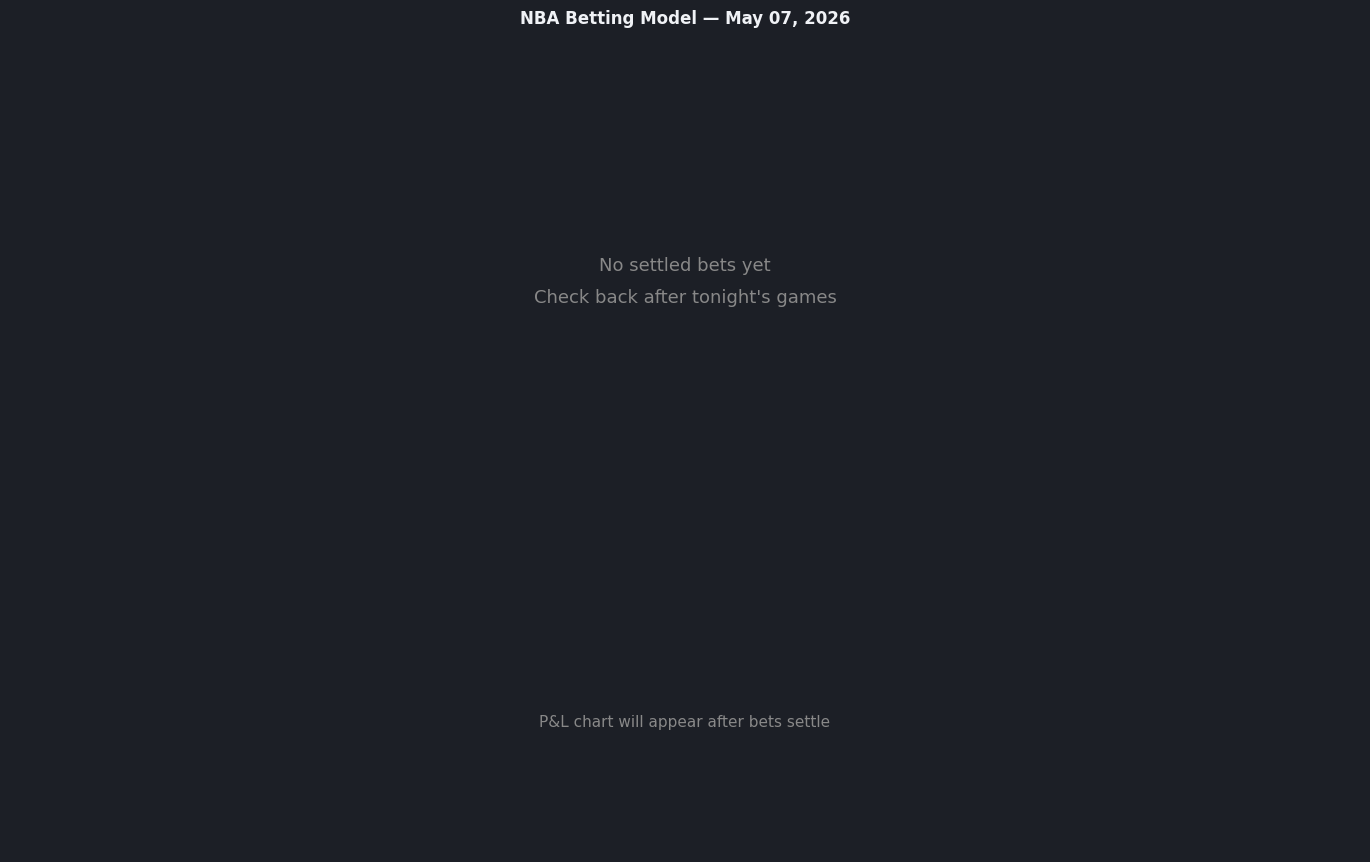

✅ Chart saved as nba_model.png
   Record:  0W - 0L - 0P
   Net P&L: $+0.00  |  ROI: 0.0%


In [11]:
# ── SHOW CHART ───────────────────────────────────────────────────
def show_chart():
    bets    = load_bets()
    df      = pd.DataFrame(bets)
    settled = df[df["result"].isin(["W","L","P"])].reset_index(drop=True)

    wins      = int((settled["result"] == "W").sum())
    losses    = int((settled["result"] == "L").sum())
    pushes    = int((settled["result"] == "P").sum())
    total_pnl = round(df["pnl"].sum(), 2)
    stake_sum = df["stake"].sum()
    roi       = (total_pnl / stake_sum * 100) if stake_sum > 0 else 0
    win_pnl   = round(settled[settled["result"] == "W"]["pnl"].sum(), 2)
    loss_pnl  = round(settled[settled["result"] == "L"]["pnl"].sum(), 2)

    fig = plt.figure(figsize=(15, 10))
    fig.patch.set_facecolor("#1c1f26")
    ax_bars = fig.add_axes([0.05, 0.38, 0.90, 0.50])
    ax_line = fig.add_axes([0.05, 0.06, 0.90, 0.26])

    ax_bars.set_facecolor("#1c1f26")
    if not settled.empty:
        bar_vals   = settled["pnl"].tolist()
        bar_colors = ["#1D9E75" if r == "W" else
                      "#D85A30" if r == "L" else "#888880"
                      for r in settled["result"]]
        bar_labels = [f"{row['pick']}\n{row['game']}\n{row['date']}"
                      for _, row in settled.iterrows()]
        x    = np.arange(len(bar_labels))
        bars = ax_bars.bar(x, bar_vals, color=bar_colors,
                           width=0.55, edgecolor="#1c1f26",
                           linewidth=1.5)
        for bar, val in zip(bars, bar_vals):
            ax_bars.text(
                bar.get_x() + bar.get_width() / 2,
                val + (abs(val) * 0.06 + 1) * (1 if val >= 0 else -1),
                f"${val:+.0f}",
                ha="center",
                va="bottom" if val >= 0 else "top",
                color="white", fontsize=9, fontweight="bold"
            )
        for j, (_, row) in enumerate(settled.iterrows()):
            if row.get("actual"):
                ax_bars.text(
                    j, min(bar_vals) * 1.2,
                    row["actual"],
                    ha="center", color="#666",
                    fontsize=7, style="italic"
                )
        nc = "#1D9E75" if total_pnl >= 0 else "#D85A30"
        ax_bars.text(0.01, 1.16,
                     f"✅  {wins} WINS   +${win_pnl:.2f}",
                     transform=ax_bars.transAxes,
                     color="#1D9E75", fontsize=12, fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.5",
                               facecolor="#0d2b1e", edgecolor="#1D9E75"))
        ax_bars.text(0.5, 1.16,
                     f"NET  ${total_pnl:+.2f}  |  ROI {roi:.1f}%",
                     transform=ax_bars.transAxes,
                     color=nc, fontsize=12, fontweight="bold",
                     ha="center",
                     bbox=dict(boxstyle="round,pad=0.5",
                               facecolor="#1c1f26", edgecolor=nc))
        ax_bars.text(0.99, 1.16,
                     f"❌  {losses} LOSSES   -${abs(loss_pnl):.2f}",
                     transform=ax_bars.transAxes,
                     color="#D85A30", fontsize=12, fontweight="bold",
                     ha="right",
                     bbox=dict(boxstyle="round,pad=0.5",
                               facecolor="#2b0d0d", edgecolor="#D85A30"))
        ax_bars.axhline(0, color="#555", linewidth=1, linestyle="--")
        ax_bars.set_xticks(x)
        ax_bars.set_xticklabels(bar_labels, color="#aaa",
                                 fontsize=8, rotation=10, ha="right")
        ax_bars.set_ylabel("P&L ($)", color="#aaa", fontsize=9)
        ax_bars.tick_params(axis="y", colors="#aaa")
        ax_bars.set_title(
            f"NBA Betting Model — Bet Results  "
            f"({wins}W - {losses}L - {pushes}P)",
            color="#f0f2f6", fontsize=12, fontweight="bold", pad=55)
        for spine in ax_bars.spines.values():
            spine.set_edgecolor("#2d3139")
    else:
        ax_bars.text(0.5, 0.5,
                     "No settled bets yet\nCheck back after tonight's games",
                     ha="center", va="center", color="#888",
                     fontsize=13, transform=ax_bars.transAxes,
                     linespacing=2)
        ax_bars.set_title(
            f"NBA Betting Model — {datetime.now().strftime('%B %d, %Y')}",
            color="#f0f2f6", fontsize=12, fontweight="bold")
        ax_bars.axis("off")

    ax_line.set_facecolor("#1c1f26")
    if not settled.empty:
        cumul = settled["pnl"].cumsum().reset_index(drop=True)
        cx    = [-1]  + cumul.index.tolist()
        cy    = [0.0] + cumul.values.tolist()
        for j in range(len(cx) - 1):
            sc = "#1D9E75" if cy[j+1] >= 0 else "#D85A30"
            ax_line.plot([cx[j], cx[j+1]], [cy[j], cy[j+1]],
                         color=sc, linewidth=2.5, zorder=3)
        ax_line.fill_between(cx, 0, cy,
                             where=[v >= 0 for v in cy],
                             alpha=0.20, color="#1D9E75",
                             interpolate=True)
        ax_line.fill_between(cx, 0, cy,
                             where=[v < 0 for v in cy],
                             alpha=0.20, color="#D85A30",
                             interpolate=True)
        rng = max(cy) - min(cy) if max(cy) != min(cy) else 1
        for px, py in zip(cx[1:], cy[1:]):
            dc = "#1D9E75" if py >= 0 else "#D85A30"
            ax_line.plot(px, py, "o", color=dc, markersize=7, zorder=5)
            ax_line.text(px, py + rng * 0.10, f"${py:.0f}",
                         ha="center", color="#ddd",
                         fontsize=8, fontweight="bold")
        ax_line.axhline(0, color="#555", linewidth=1, linestyle="--")
        ax_line.set_ylabel("Cumulative P&L ($)", color="#aaa", fontsize=9)
        ax_line.set_xlabel("Bet number", color="#aaa", fontsize=9)
        ax_line.set_title("Cumulative P&L Over Time",
                          color="#f0f2f6", fontsize=11)
        ax_line.set_xticks(cx[1:])
        ax_line.tick_params(colors="#aaa")
        for spine in ax_line.spines.values():
            spine.set_edgecolor("#2d3139")
    else:
        ax_line.text(0.5, 0.5,
                     "P&L chart will appear after bets settle",
                     ha="center", va="center", color="#888",
                     fontsize=11, transform=ax_line.transAxes)
        ax_line.axis("off")

    plt.savefig("nba_model.png", dpi=150,
                bbox_inches="tight", facecolor="#1c1f26")
    plt.show()
    print(f"✅ Chart saved as nba_model.png")
    print(f"   Record:  {wins}W - {losses}L - {pushes}P")
    print(f"   Net P&L: ${total_pnl:+.2f}  |  ROI: {roi:.1f}%")

# ── RUN IT ───────────────────────────────────────────────────────
auto_settle()
print()
show_chart()

In [12]:
# ── AUTO SETTLE — MATCHES BY DATE AND TEAMS ─────────────────────
def auto_settle():
    bets          = load_bets()
    settled_count = 0

    print("🔄 Checking ESPN scores against pending bets...\n")

    for i, bet in enumerate(bets):
        if bet["result"] != "pending":
            continue

        try:
            away_team = bet["game"].split("@")[0].strip().split()[-1]
            home_team = bet["game"].split("@")[1].strip().split()[0]
        except:
            print(f"  ⚠️ Could not parse: {bet['game']}")
            continue

        # Pull ESPN scores for the EXACT date the bet was placed
        bet_date_espn = bet["date"].replace("-", "")
        url = (
            f"https://site.api.espn.com/apis/site/v2/sports/"
            f"basketball/nba/scoreboard?dates={bet_date_espn}"
        )
        try:
            r      = requests.get(url, timeout=10)
            events = r.json().get("events", [])
        except:
            print(f"  ⚠️ ESPN error for {bet_date_espn}")
            continue

        # Find matching game by date AND teams
        score = None
        for e in events:
            status = e["status"]["type"]["description"]
            comps  = e["competitions"][0]
            teams  = comps["competitors"]
            home   = next(t for t in teams if t["homeAway"] == "home")
            away   = next(t for t in teams if t["homeAway"] == "away")
            h_code = NAME_TO_CODE.get(
                home["team"]["displayName"],
                home["team"]["abbreviation"]
            )
            a_code = NAME_TO_CODE.get(
                away["team"]["displayName"],
                away["team"]["abbreviation"]
            )
            if ((a_code == away_team and h_code == home_team) or
                (a_code == home_team and h_code == away_team)):
                if status != "Final":
                    print(f"  ⏳ {bet['game']} on {bet['date']} "
                          f"— not final yet [{status}]")
                    score = None
                    break
                h_score = int(home["score"]) if home["score"] else 0
                a_score = int(away["score"]) if away["score"] else 0
                score = {
                    "home":       h_code,
                    "away":       a_code,
                    "home_score": h_score,
                    "away_score": a_score,
                }
                break

        if not score:
            continue

        home    = score["home"]
        away    = score["away"]
        h_score = score["home_score"]
        a_score = score["away_score"]
        margin  = h_score - a_score
        pick    = bet["pick"]
        odds    = bet["odds"]
        stake   = bet["stake"]
        result  = "P"

        if bet["type"] == "SPREAD":
            try:
                parts      = pick.split()
                team       = parts[0]
                spread_val = float(parts[1])
            except:
                continue
            adj    = (margin + spread_val if team == home
                      else (-margin) + spread_val)
            result = "P" if adj == 0 else ("W" if adj > 0 else "L")

        elif bet["type"] == "TOTAL":
            try:
                parts      = pick.split()
                direction  = parts[0].upper()
                total_line = float(parts[1])
            except:
                continue
            actual = h_score + a_score
            if actual == total_line:
                result = "P"
            elif direction == "OVER":
                result = "W" if actual > total_line else "L"
            else:
                result = "W" if actual < total_line else "L"

        elif bet["type"] == "ML":
            try:
                team = pick.split()[0]
            except:
                continue
            winner = home if h_score > a_score else away
            result = "W" if team == winner else "L"

        pnl = (round(stake * abs(odds) / 100
                     if odds > 0
                     else stake * 100 / abs(odds), 2)
               if result == "W" else
               -stake if result == "L" else 0.0)

        bets[i]["result"] = result
        bets[i]["pnl"]    = pnl
        bets[i]["actual"] = f"{away} {a_score} @ {home} {h_score}"
        settled_count    += 1
        time.sleep(0.3)

        emoji = "✅" if result == "W" else ("❌" if result == "L" else "➖")
        print(f"  {emoji}  {pick:25s} | "
              f"{away} {a_score} @ {home} {h_score} | "
              f"{result} | ${pnl:+.2f}")

    if settled_count > 0:
        save_bets(bets)
        print(f"\n  ✅ {settled_count} bet(s) settled!")
    else:
        print("  ⏳ No bets settled yet — "
              "check back after tonight's games finish")

print("✅ auto_settle ready — matches by date AND teams")

✅ auto_settle ready — matches by date AND teams


  🏀 NBA MODEL — May 07, 2026 04:46 PM

📡 Pulling live data...

   API requests remaining: 467

  ✅ Ratings : 16 teams from NBA.com
  ✅ Games   : 2 today from NBA.com
  ✅ Odds    : 4 games from The Odds API
  ✅ Scores  : 4 recent games from ESPN

───────────────────────────────────────────────────────
🔄 Checking ESPN scores against pending bets...

  ⏳ CLE @ DET on 2026-05-07 — not final yet [Scheduled]
  ⏳ CLE @ DET on 2026-05-07 — not final yet [Scheduled]
  ⏳ CLE @ DET on 2026-05-07 — not final yet [Scheduled]
  ⏳ LAL @ OKC on 2026-05-07 — not final yet [Scheduled]
  ⏳ LAL @ OKC on 2026-05-07 — not final yet [Scheduled]
  ⏳ No bets settled yet — check back after tonight's games finish

───────────────────────────────────────────────────────

📊 Today's picks:

  🏀 CLE @ DET  |  7:00 pm ET
  ────────────────────────────────────────────────
  SPREAD  Mkt:-3.5  Mdl:-7.5  Edge:+4.0  →  LAY DET
  TOTAL   Mkt:215.5  Mdl:206.1  Edge:+9.4  →  UNDER 215.5 🎯
  ML      DET: 55% win  | ⭐ A — Stro

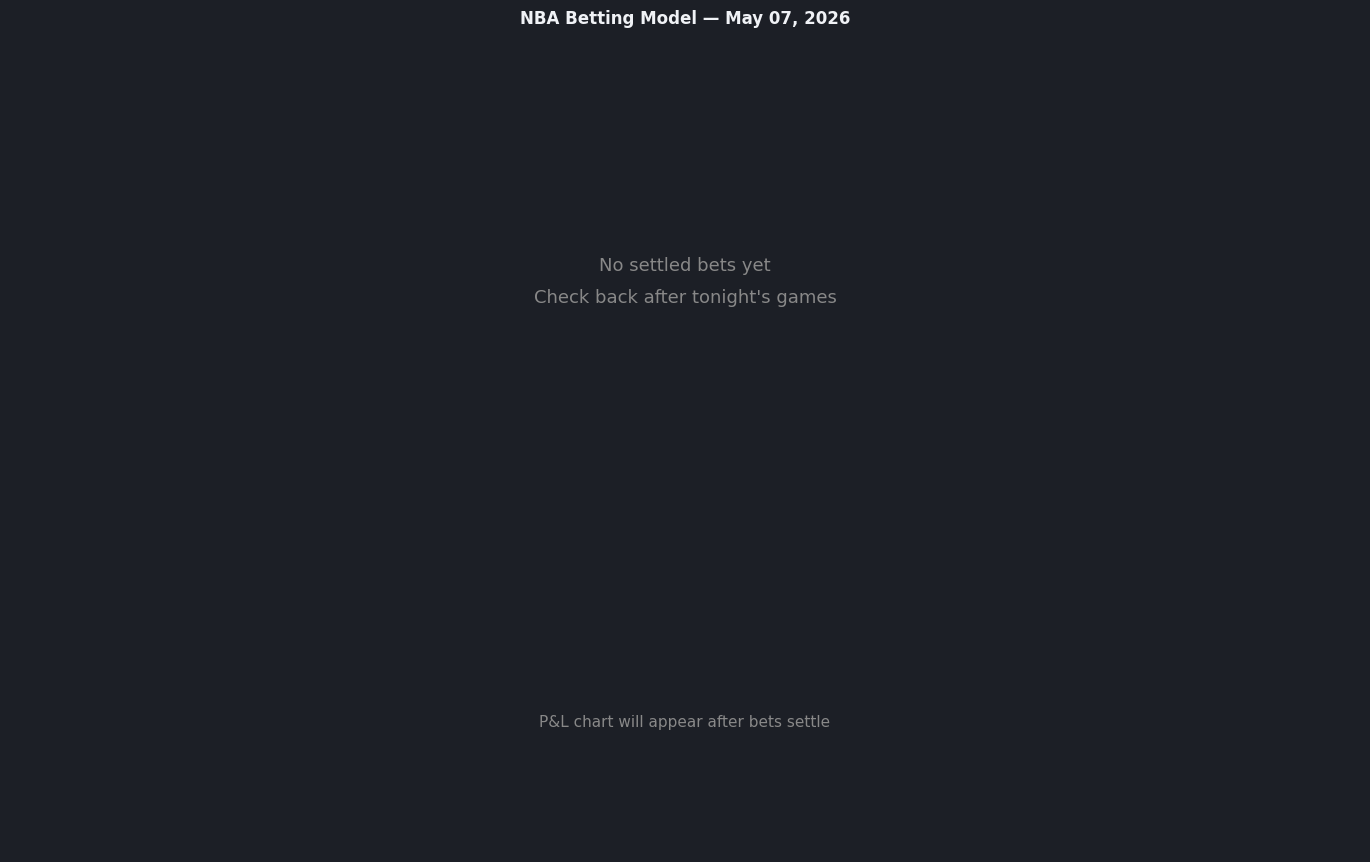

✅ Chart saved as nba_model.png
   Record:  0W - 0L - 0P
   Net P&L: $+0.00  |  ROI: 0.0%

  ⚠️  For entertainment only. 1-800-GAMBLER


In [13]:
# ════════════════════════════════════════════════════════════════
#  🏀 DAILY ROUTINE — run this one cell every morning
#  
#  It will automatically:
#  1. Pull live team ratings from NBA.com
#  2. Pull today's games from NBA.com  
#  3. Pull live odds from The Odds API
#  4. Pull final scores from ESPN
#  5. Settle any pending bets
#  6. Run model on today's games
#  7. Log today's picks
#  8. Draw the full chart
# ════════════════════════════════════════════════════════════════

print("=" * 55)
print(f"  🏀 NBA MODEL — {datetime.now().strftime('%B %d, %Y %I:%M %p')}")
print("=" * 55)

# ── 1. LIVE DATA ─────────────────────────────────────────────────
print("\n📡 Pulling live data...\n")
df_teams = get_live_team_stats()
games    = get_todays_games()
odds     = get_live_odds()
finals   = get_espn_scores(days_back=3)
print(f"\n  ✅ Ratings : {len(df_teams)} teams from NBA.com")
print(f"  ✅ Games   : {len(games)} today from NBA.com")
print(f"  ✅ Odds    : {len(odds)} games from The Odds API")
print(f"  ✅ Scores  : {len(finals)} recent games from ESPN")

# ── 2. SETTLE PENDING BETS ───────────────────────────────────────
print("\n" + "─" * 55)
auto_settle()

# ── 3. RUN MODEL ─────────────────────────────────────────────────
print("\n" + "─" * 55)
print("\n📊 Today's picks:\n")
results = []
for g in games:
    home = g["home"]
    away = g["away"]
    line = (odds.get((away, home)) or odds.get((home, away)))
    if not line or line["spread"] is None:
        print(f"  ⚠️ No odds for {away} @ {home}")
        continue
    pred = predict_game(
        home          = home,
        away          = away,
        market_spread = line["spread"],
        market_total  = line["total"],
        mkt_home_ml   = line["home_ml"],
        mkt_away_ml   = line["away_ml"],
        is_playoff    = True,
    )
    if not pred:
        continue
    results.append(pred)
    print(f"  🏀 {away} @ {home}  |  {g['time']}")
    print(f"  {'─' * 48}")
    print(f"  SPREAD  Mkt:{pred['market_spread']:+.1f}  "
          f"Mdl:{pred['model_spread']:+.1f}  "
          f"Edge:{pred['spread_edge']:+.1f}  "
          f"→  {pred['spread_pick']}")
    print(f"  TOTAL   Mkt:{pred['market_total']}  "
          f"Mdl:{pred['model_total']}  "
          f"Edge:{pred['total_edge']:+.1f}  "
          f"→  {pred['total_pick']}")
    print(f"  ML      {home}: {pred['home_win_prob']:.0%} win  "
          f"| {pred['tier']}  "
          f"| {pred['confidence']:.0%} conf")
    print(f"  SHARP   {pred['sharp_signal']} "
          f"(Δ {pred['sharp_delta']:+.0f}%)\n")

# ── 4. LOG TODAY'S PICKS ─────────────────────────────────────────
print("─" * 55)
print("\n📝 Auto-logging picks...\n")
auto_log_todays_picks(results, odds)

# ── 5. DRAW CHART ────────────────────────────────────────────────
print("\n" + "─" * 55)
print("\n📈 Drawing chart...\n")
show_chart()

print("\n" + "=" * 55)
print("  ⚠️  For entertainment only. 1-800-GAMBLER")
print("=" * 55)